# 09 — Mushroom-modelvergelijking: Andrew + Jorre/AWS

**Bijdragen:** Andrew Noeyens maakte de oorspronkelijke lokale modeldefinities en exports;
Jorre Van Dyck trainde en exporteerde het AWS-model; Codex controleerde het artifact,
trainde de configuraties lokaal op gedeelde data, controleerde generalisatie naar ongeziene
soorten en maakte deze vergelijking op verzoek van Jorre.
Teamreview en mondelinge verdediging staan nog open. AI-gebruik is expliciet vermeld.

Dit is het hoofdnotebook volgens de opdracht: metrics verzamelen, eerlijk vergelijken,
fouten onderzoeken en een keuze motiveren. De volledige uitleg staat in
[09_vergelijkingsrapport.md](09_vergelijkingsrapport.md).
Nieuwe hertrainingen zijn lokaal uitgevoerd, niet opnieuw op AWS.


## 1. Omgeving en resultaten laden

Het originele AWS-model wordt alleen met scikit-learn 1.7.2 geladen via `audit_aws_model.py`.
De nieuwe fits gebruiken 1.9.1 voor alle kandidaten. Gebruik de twee omgevingen uit het rapport.
Hier lezen we standaard de opgeslagen audit en evaluaties. Zet `RUN_TRAINING=True` voor een
nieuwe volledige gemeenschappelijke training; het script legt de CV-keuze vast vóór testmetrics.
Voer daarna de rapportgenerator opnieuw uit om tekst en cijfers gelijk te houden.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'SolutionJorre/MushroomDataset/aws_results.json').exists())
FOLDER = ROOT / 'secondary_mushroom'
OUT = FOLDER / 'comparison_team'
sys.path.insert(0, str(FOLDER))
from compare_team_models import run, NAMES

RUN_TRAINING = False
if RUN_TRAINING:
    run()
summary = json.loads((OUT / 'shared_comparison_summary.json').read_text(encoding='utf-8'))
audit = json.loads((OUT / 'aws_artifact_audit.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(OUT / 'shared_model_comparison.csv').set_index('model')
folds = pd.read_csv(OUT / 'shared_cv_folds.csv')
split = pd.read_csv(OUT / 'shared_split_manifest.csv')
predictions = pd.read_csv(OUT / 'shared_test_predictions.csv')
artifact_predictions = pd.read_csv(OUT / 'aws_artifact_predictions.csv')
errors = pd.read_csv(OUT / 'shared_error_records.csv')
display(pd.DataFrame([audit['environment'], summary['environment']], index=['AWS artifact-audit', 'gemeenschappelijke nieuwe fits']))
print('Voorlopige voorkeur binnen de random split:', NAMES[summary['selected_model']])

,python,sklearn,numpy,pandas,scipy,joblib,platform,logical_cpus,xgboost
AWS artifact-audit,3.13.7,1.7.2,2.2.6,2.3.3,1.15.3,1.6.0,NaN,NaN,NaN
gemeenschappelijke nieuwe fits,3.13.7,1.9.1,2.5.3,3.0.2,1.18.1,1.6.0,Windows-11-10.0.26200-SP0,20.0,3.4.1


Voorlopige voorkeur binnen de random split: Jorre AWS RF100 (getuned)


## 2. Oorspronkelijke resultaten en data-identiteit


| Oorspronkelijk experiment | Data / features | Testset | Gemelde testaccuracy | Status |
| --- | --- | --- | --- | --- |
| Andrew RF500 | Eigen CSV: 5.000 rijen, 12 features inclusief twee noise-velden | 900, gestratificeerd 18%, seed 42 | 81,00% | Eerder exact op bronprecisie gereproduceerd |
| Andrew Gradient Boosting | Dezelfde Andrew-data | Dezelfde 900 | 80,89% | Eerder gereproduceerd en opgeslagen pipeline gecontroleerd |
| Andrew XGBoost | Dezelfde Andrew-data | Dezelfde 900 | 78,67% | Eerder gereproduceerd met oorspronkelijke `n_jobs=-1` |
| Andrew Logistic + poly | Dezelfde Andrew-data | Dezelfde 900 | 67,11% | Eerder gereproduceerd |
| Andrew Logistic v1-config | Andere opgeslagen LR-configuratie, zelfde Andrew-data | Dezelfde 900 in gecontroleerde hertraining | 70,89% | Apart gehouden van notebook-LR |
| Jorre AWS RF100 getuned | UCI: 60.923 unieke rijen, 20 features | 12.185, gestratificeerd 20%, seed 42 | 100,00% | Opgeslagen model nu opnieuw op deze records gecontroleerd |

De eerdere Andrew RF200 in de API hoort bij een andere 80/20-split met 1.000 testrecords.
Zijn 78,2% is een historisch deploymentresultaat, geen score voor de nieuwe RF500-configuratie.

Voor de gezamenlijke vergelijking downloaden we met code het oorspronkelijke
[UCI-archief](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset).
Er zijn 61.069 oorspronkelijke rijen en twintig kenmerken. Na het verwijderen van
146 exacte duplicaten blijven 60.923 rijen over. `p` bevat giftige én niet aanbevolen
paddenstoelen met onbekende eetbaarheid; de gegevens zijn gesimuleerd vanuit 173 soorten.

Alle kandidaten krijgen de **zelfde 48.738 trainingsrecords en 12.185 testrecords**.
De testset heeft 5.436 `e` en 6.749 `p`. De invoer bevat de twintig bronfeatures, geen doelkolom
en geen Andrew-noisevelden. De raw-CSV heeft LF-genormaliseerde SHA-256
`a0d68cfc46c6900d67d30a49c6e1c3b8c37042dbd6e62ce38a9cf84a40c022e0`. De herkomst- en splitbestanden maken de rij-identiteit controleerbaar.

Er is **0 exacte feature-overlap** tussen
train en test. Deze check sluit afhankelijkheden binnen de simulatie of nabijgelegen
records niet uit. In de oorspronkelijke vergelijking werden geen soortgroepen gebruikt.
De aanvullende audit reconstrueert en controleert die groepen tegen de primaire UCI-data:
alle **173 soorten** komen in zowel de random trainingsset als de testset voor.



In [2]:
assert len(split) == 60923 and split.unique_row.is_unique and split.source_row.is_unique
assert (split.split == 'train').sum() == 48738
assert (split.split == 'test').sum() == 12185
assert split.loc[split.split == 'train', 'cv_validation_fold'].notna().all()
assert split.loc[split.split == 'test', 'cv_validation_fold'].isna().all()
assert set(predictions.unique_row) == set(split.loc[split.split == 'test', 'unique_row'])
assert predictions.unique_row.tolist() == artifact_predictions.unique_row.tolist()
assert summary['dataset']['sha256_lf'] == audit['csv_sha256_lf']
display(pd.crosstab(split.split, split['class']))
display(split.loc[split.split == 'train', 'cv_validation_fold'].value_counts().sort_index())
display(pd.Series(summary['dataset']['missing_percent'], name='ontbrekend (%)'))

class,e,p
split,,
test,5436,6749
train,21745,26993


cv_validation_fold
1.0    16246
2.0    16246
3.0    16246
Name: count, dtype: int64

cap-diameter             0.000000
cap-shape                0.000000
cap-surface             23.176797
cap-color                0.000000
does-bruise-or-bleed     0.000000
gill-attachment         16.176157
gill-spacing            41.137173
gill-color               0.000000
stem-height              0.000000
stem-width               0.000000
stem-root               84.592026
stem-surface            62.574069
stem-color               0.000000
veil-type               94.785221
veil-color              87.832182
has-ring                 0.000000
ring-type                4.055939
spore-print-color       89.616401
habitat                  0.000000
season                   0.000000
Name: ontbrekend (%), dtype: float64

## 3. Audit van het opgeslagen AWS-model


Het artifact in [SolutionJorre/MushroomDataset](../SolutionJorre/MushroomDataset/) bevat
preprocessing én een Random Forest: 100 bomen, maximale diepte 24, minimaal twee records
per leaf, seed 42 en twee threads. Numerieke waarden krijgen de trainingsmediaan;
categorische ontbrekende waarden worden `missing`, gevolgd door one-hot encoding.
AWS is hier de trainingsomgeving; het modelalgoritme is scikit-learn Random Forest.

De controle reconstrueert de exacte AWS-split vanaf de brondata. De opgeslagen pipeline
verwacht twintig features en maakt 128 encoded features; `class` is uitgesloten.
Er waren geen versie- of inferentiewaarschuwingen. De opnieuw berekende confusion matrix is:

```text
              voorspeld e    voorspeld p
werkelijk e          5436              0
werkelijk p             0           6749
```

Accuracy, precision p, recall p, F1 p, ROC-AUC en AP zijn opnieuw 1,0. De modelhash is
`6f2e527adf52ad598b49925690009fa4ee2fc97bda19dfb2d07a802664aa1b53`. Het artifact is niet gewijzigd of opnieuw getraind.
Een afzonderlijk bewaard trainingsmanifest van de oorspronkelijke AWS-run ontbreekt;
trainingslidmaatschap van dat artifact is dus niet onafhankelijk bewezen. De gecontroleerde
nieuwe fit heeft wel een vastgelegd train/test-manifest zonder train-testoverlap.

Het AWS-notebook testte vier RandomizedSearchCV-kandidaten met drie trainingsfolds:

| Bomen | Max depth | Min leaf | CV F1 | SD | Rank |
| --- | --- | --- | --- | --- | --- |
| 100 | 24 | 2 | 1.000000 | 0.000000 | 1 |
| 200 | 24 | 1 | 1.000000 | 0.000000 | 1 |
| 100 | Geen limiet | 1 | 1.000000 | 0.000000 | 1 |
| 100 | 24 | 1 | 1.000000 | 0.000000 | 1 |

Alle kandidaten én de AWS-baseline hadden CV F1=1,0. De tuning levert hier dus **geen
gemeten verbetering**. De bronsearch kiest de eerste kandidaat uit de gedeelde beste
rank; uit deze tabel volgt niet dat depth 24/leaf 2 uniek optimaal is.

De auditomgeving gebruikt dezelfde scikit-learn 1.7.2 en pandas 2.3.3 als de export.
Python/NumPy verschillen van de SageMaker-omgeving (hier 3.13.7/2.2.6, oorspronkelijk
3.10.20/1.26.4); de vastgelegde inferentie-uitkomsten komen overeen. Voor de gezamenlijke
nieuwe fits gebruiken alle modellen dezelfde scikit-learn 1.9.1-omgeving.



In [3]:
import hashlib
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
artifact_path = ROOT / 'SolutionJorre/MushroomDataset/mushroom_pipeline.joblib'
assert hashlib.sha256(artifact_path.read_bytes()).hexdigest() == audit['artifact_sha256']
y_original = (artifact_predictions.true_class == 'p').astype(int)
labels_original = (artifact_predictions.prediction == 'p').astype(int)
original_cm = confusion_matrix(y_original, labels_original, labels=[0, 1])
assert original_cm.tolist() == [[5436, 0], [0, 6749]]
assert not audit['warnings'] and audit['matches_exported_metrics']
display(pd.Series(audit['recomputed_metrics'], name='opnieuw berekend op origineel artifact'))
display(pd.read_csv(ROOT / 'SolutionJorre/MushroomDataset/aws_tuning_results.csv')
    [['param_model__n_estimators', 'param_model__max_depth', 'param_model__min_samples_leaf', 'mean_test_score', 'std_test_score', 'rank_test_score']])

accuracy                1.0
balanced_accuracy       1.0
precision               1.0
recall                  1.0
f1                      1.0
roc_auc                 1.0
average_precision       1.0
tn                   5436.0
fp                      0.0
fn                      0.0
tp                   6749.0
Name: opnieuw berekend op origineel artifact, dtype: float64

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,100,24.0,2,1.0,0.0,1
1,200,24.0,1,1.0,0.0,1
2,100,NaN,1,1.0,0.0,1
3,100,24.0,1,1.0,0.0,1


## 4. Gezamenlijk protocol en modelkeuze


De featurekolommen van Andrew's configuraties worden uitgebreid naar de twintig UCI-features;
de oorspronkelijke noise-kolommen worden niet verzonnen of ingevuld. Zijn hyperparameters
blijven gelijk. De LR-v1 wordt gekloond zodat opgeslagen aangeleerde toestand verdwijnt,
met behoud van missing indicators, scaling en classifierinstellingen; de kolomselectie
wordt aangepast. Het getrainde v1-artifact zelf wordt niet voor deze UCI-scores gebruikt.

| Configuratie | Preprocessing en belangrijkste instellingen |
| --- | --- |
| AWS RF100 getuned | Numerieke mediaan; categorisch `missing` + OHE; 100 bomen, depth 24, leaf 2 |
| AWS RF100 baseline | Dezelfde AWS-preprocessing; 100 bomen, geen depth-limiet, leaf 1 |
| Andrew RF500 | Nullen in stemmetingen → ontbrekend; numerieke mediaan; categorische modus + OHE; 500 bomen, depth 20, split 3, leaf 1, balanced |
| Andrew Gradient Boosting | Dezelfde Andrew-preprocessing; 350 bomen, learning rate 0,08, depth 8, split 4, leaf 2 |
| Andrew XGBoost | Dezelfde Andrew-preprocessing; 500 bomen, learning rate 0,05, depth 5, min child weight 2, subsample/colsample 0,8 |
| Andrew Logistic + poly | Andrew-schoonmaak; mediaan + numerieke polynomial features graad 2 + scaling; C=1, balanced, max iter 3.000 |
| Andrew Logistic v1-config | Andrew-schoonmaak; mediaan + missing indicators + scaling; categorische modus + OHE; C=1, geen class weights, max iter 2.000 |
| Meerderheidsreferentie | Voorspelt steeds de meerderheidsklasse `p` in deze UCI-versie |

We vergelijken **volledige pipelineconfiguraties**, dus verschillen kunnen uit preprocessing
én classifierinstellingen komen. Dit is geen geïsoleerde causaliteitsproef van één algoritme.
Andrew's nulmetingen-schoonmaak is overgenomen voor reproductie; haar inhoudelijke noodzaak
op de volledige UCI-data is hiermee niet bewezen en vraagt nog een afzonderlijke EDA/ablation.

Op de gedeelde trainingsset gebruiken we drie identieke gestratificeerde folds met shuffle
en seed 42, zoals in de AWS-opzet. Imputatie, encoding, scaling en modeltraining worden
uitsluitend op de trainingsrecords van elke fold gefit. Er is geen nieuwe hyperparametersearch.
De selectie gebruikt gemiddelde CV F1 p, daarna CV recall p. Bij exacte gelijke beste scores
staat de beschikbare, geregulariseerde AWS RF100 vooraf eerst in de voorkeurvolgorde.
De keuze wordt vastgelegd **vóór** het berekenen van de gemeenschappelijke testmetrics.

F1 balanceert precision en recall; FN en recall p blijven afzonderlijk zichtbaar omdat
giftig als eetbaar een ander fouttype is dan eetbaar als giftig. F1 is geen veiligheidsnorm.
De standaard `predict`-drempel rond 0,5 blijft behouden. Er is geen tuning of drempelkeuze
op test gedaan. Zie het [validatieprotocol](https://scikit-learn.org/stable/modules/cross_validation.html).



In [4]:
ranking = metrics.sort_values(['cv_f1_mean', 'cv_recall_mean'], ascending=False, kind='stable')
assert ranking.index[0] == summary['selected_model']
assert len(folds) == 24 and (folds.groupby('model').size() == 3).all()
display(ranking[['cv_f1_mean', 'cv_f1_std', 'cv_recall_mean', 'cv_accuracy_mean']].round(6))
display(folds.pivot(index='fold', columns='model', values='f1_poisonous').round(6))
print('Exact gelijke beste CV-scores:', summary['exact_cv_ties'])

,cv_f1_mean,cv_f1_std,cv_recall_mean,cv_accuracy_mean
model,,,,
aws_tuned,1.000000,0.000000,1.000000,1.000000
aws_baseline,1.000000,0.000000,1.000000,1.000000
gradient_boosting,0.999926,0.000032,0.999889,0.999918
random_forest_500,0.999666,0.000255,0.999370,0.999631
xgboost,0.998424,0.000569,0.997740,0.998256
logistic_polynomial,0.854479,0.003246,0.823621,0.844639
logistic_artifact_config,0.854227,0.002338,0.840922,0.841048
majority,0.712865,0.000029,1.000000,0.553839


model,aws_baseline,aws_tuned,gradient_boosting,logistic_artifact_config,logistic_polynomial,majority,random_forest_500,xgboost
fold,,,,,,,,
1,1.0,1.0,0.999944,0.851714,0.850896,0.712831,0.999388,0.997774
2,1.0,1.0,0.999944,0.854630,0.855315,0.712882,0.999722,0.998833
3,1.0,1.0,0.999889,0.856337,0.857225,0.712882,0.999889,0.998665


Exact gelijke beste CV-scores: ['aws_tuned', 'aws_baseline']


## 5. Gedeelde test-audit en controle tegen individuele voorspellingen

Alle kandidaten zijn opnieuw gefit op dezelfde trainingsrecords. De oorspronkelijke Andrew
modellen hadden een ander schema; dit zijn scores voor aangepaste configuraties, geen nieuwe
claims over zijn opgeslagen 12-featuremodellen. De positieve klasse is p. We herberekenen
de metrics uit de bewaarde voorspellingen om te controleren dat tabel en notebook overeenkomen.
ROC-AUC/AP meten ranking; de scores zijn niet op kalibratie getest.


,accuracy,balanced_accuracy,precision_poisonous,recall_poisonous,f1_poisonous,roc_auc,average_precision,fn,fp
model,,,,,,,,,
aws_tuned,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0
aws_baseline,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0
random_forest_500,0.999836,0.999852,1.000000,0.999704,0.999852,1.000000,1.000000,2,0
gradient_boosting,0.999836,0.999852,1.000000,0.999704,0.999852,1.000000,1.000000,2,0
xgboost,0.998112,0.998207,0.999258,0.997333,0.998294,0.999958,0.999967,18,5
logistic_polynomial,0.848748,0.850542,0.886299,0.833901,0.859302,0.922041,0.943266,1121,722
logistic_artifact_config,0.845794,0.845351,0.869163,0.849459,0.859198,0.913594,0.936073,1016,863
majority,0.553878,0.500000,0.553878,1.000000,0.712897,0.500000,0.553878,0,5436


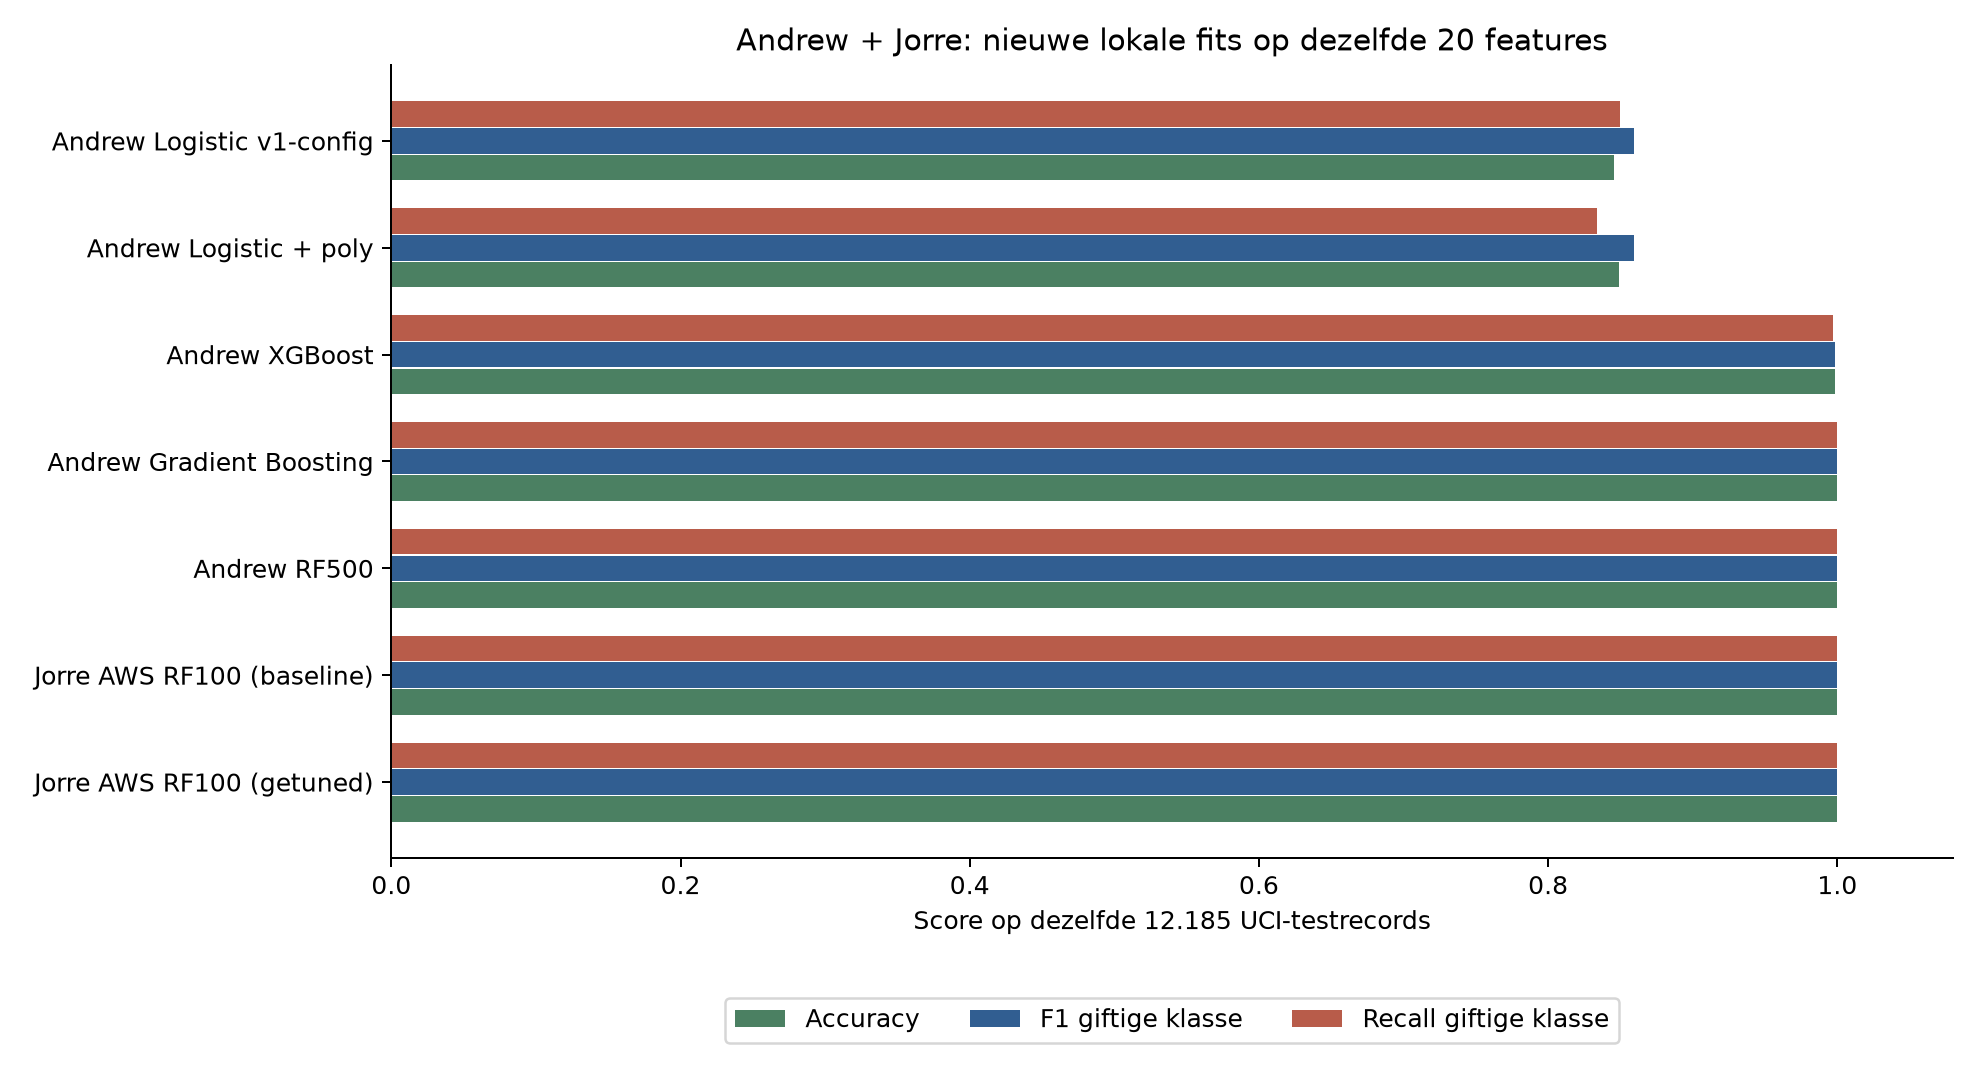

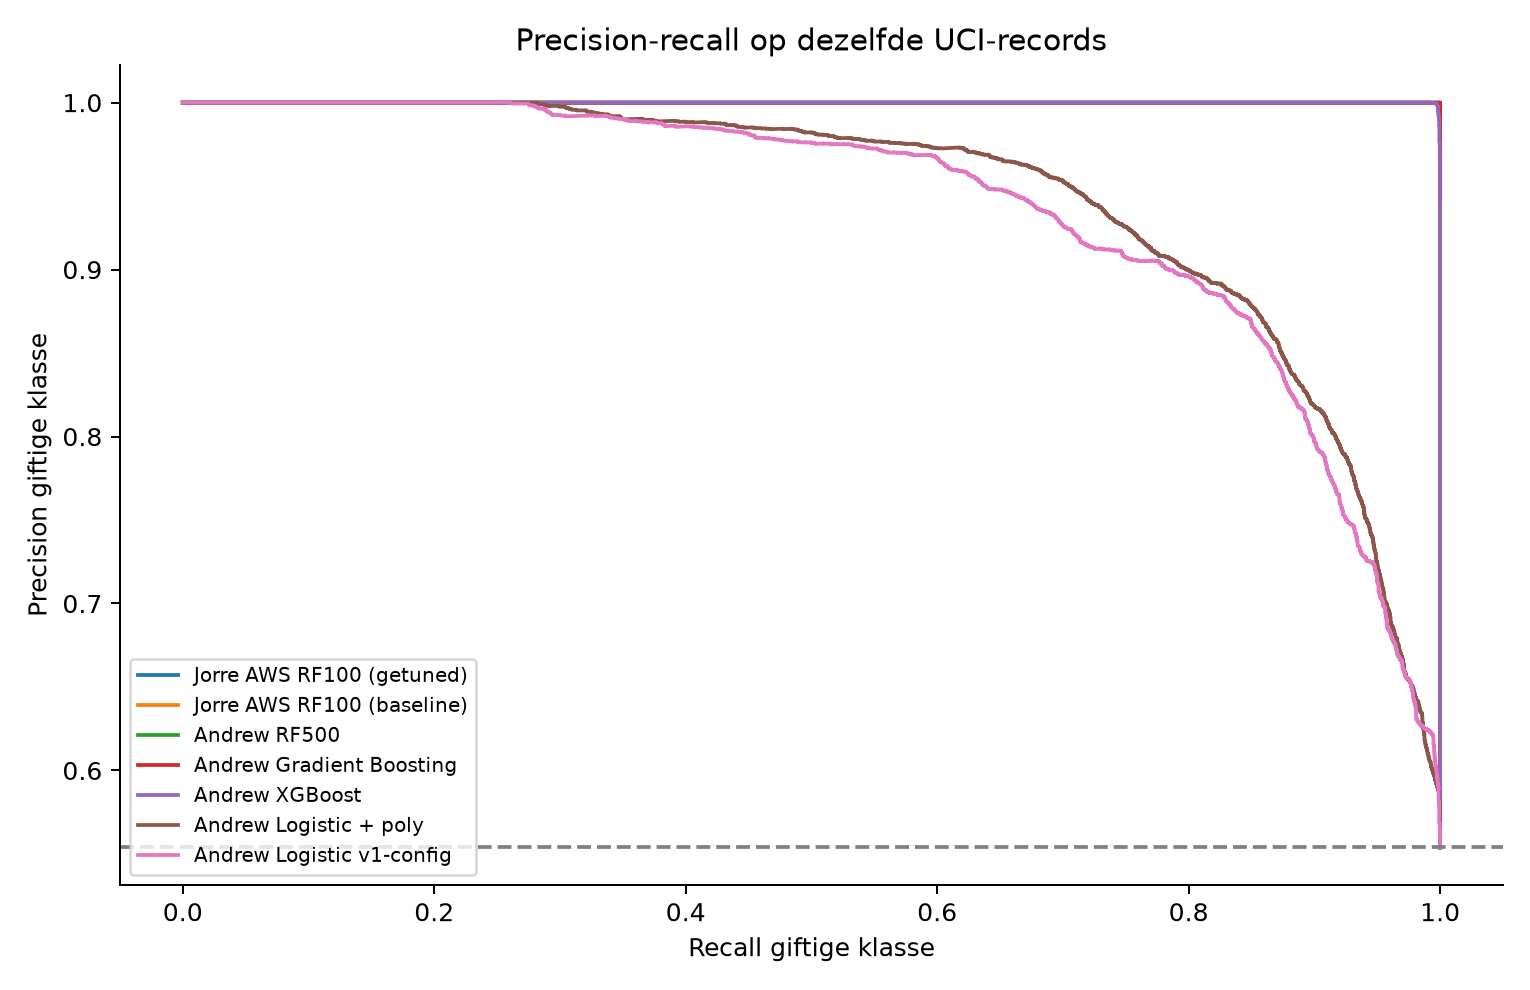

label_disagreements                   0
maximum_probability_difference      0.0
original_artifact_sklearn         1.7.2
local_refit_sklearn               1.9.1
dtype: object

In [5]:
y = (predictions.true_class == 'p').astype(int)
functions = {'accuracy': accuracy_score, 'balanced_accuracy': balanced_accuracy_score,
             'precision_poisonous': precision_score, 'recall_poisonous': recall_score, 'f1_poisonous': f1_score}
for key, row in metrics.iterrows():
    labels = (predictions[key + '_prediction'] == 'p').astype(int)
    proba = predictions[key + '_probability_p']
    for name, function in functions.items():
        actual = function(y, labels) if name in ['accuracy', 'balanced_accuracy'] else function(y, labels, zero_division=0)
        assert abs(actual - row[name]) < 1e-12
    assert abs(roc_auc_score(y, proba) - row.roc_auc) < 1e-12
    assert abs(average_precision_score(y, proba) - row.average_precision) < 1e-12
    cm = confusion_matrix(y, labels, labels=[0, 1])
    assert cm.sum() == 12185
    assert cm.ravel().tolist() == [int(row[c]) for c in ['tn', 'fp', 'fn', 'tp']]
display(metrics[['accuracy', 'balanced_accuracy', 'precision_poisonous', 'recall_poisonous', 'f1_poisonous', 'roc_auc', 'average_precision', 'fn', 'fp']].round(6))
display(Image(filename=str(OUT / 'shared_metrics.png')))
display(Image(filename=str(OUT / 'shared_pr_curves.png')))
display(pd.Series(summary['aws_local_refit_vs_original_artifact']))

## 6. Foutanalyse en onzekerheid


| Configuratie | TN e→e | FP e→p | FN p→e | TP p→p |
| --- | --- | --- | --- | --- |
| Jorre AWS RF100 (getuned) | 5436 | 0 | 0 | 6749 |
| Jorre AWS RF100 (baseline) | 5436 | 0 | 0 | 6749 |
| Andrew RF500 | 5436 | 0 | 2 | 6747 |
| Andrew Gradient Boosting | 5436 | 0 | 2 | 6747 |
| Andrew XGBoost | 5431 | 5 | 18 | 6731 |
| Andrew Logistic + poly | 4714 | 722 | 1121 | 5628 |
| Andrew Logistic v1-config | 4573 | 863 | 1016 | 5733 |
| Meerderheidsreferentie | 0 | 5436 | 0 | 6749 |

![Gemeenschappelijke confusion matrices](comparison_team/shared_confusion_matrices.png)

De gekozen configuratie maakt 0 testfouten. Het beschrijvende
Wilson-interval van 95% voor accuracy is **99.9685–100.0000%**;
voor recall p **99.9431–100.0000%**. Ook nul geobserveerde fouten
bewijst geen nul foutkans in de populatie. De intervallen veronderstellen onafhankelijke
records en corrigeren niet voor eerdere experimenten, modelselectie of simulatiestructuur.

Voor concrete fouten bekijken we de zwakste getrainde kandidaat op test-F1:
**Andrew Logistic v1-config**. Dit is een achteraf gekozen foutanalyse, geen selectie- of tuningcriterium.
Onder de onterecht eetbaar gelabelde giftige records staan de drie laagste p-scores:

| Model | Unieke rij / bronrij (0-based) | Werkelijk → voorspeld | Score p | Ontbrekende features |
| --- | --- | --- | --- | --- |
| Andrew Logistic v1-config | 58573 / 58719 | p → e | 0.005188 | 6 |
| Andrew Logistic v1-config | 58756 / 58902 | p → e | 0.008153 | 6 |
| Andrew Logistic v1-config | 58488 / 58634 | p → e | 0.011454 | 6 |

Alle foutrecords met bronfeatures zijn bewaard in
[shared_error_records.csv](comparison_team/shared_error_records.csv).
Eén tabelrij kan per foutmakend model terugkomen. Gemiddelde scores vertellen niet welke
combinaties problematisch zijn; daarom behoudt het notebook deze voorbeelden en het aantal
ontbrekende kenmerken. De voorbeelden alleen bewijzen geen oorzakelijk effect van imputatie.

Het accuracyverschil tussen AWS100 en Andrew RF500/Gradient Boosting is slechts **twee
records op 12.185**, ongeveer **0,0164 procentpunt**. Een exacte gepaarde McNemar-toets
geeft in beide vergelijkingen p=0,5: dit kleine testverschil bewijst niet dat AWS100
statistisch beter presteert. Het bewijst ook geen equivalentie.
De paarvergelijkingen in het JSON-bestand zijn exploratief, zonder meervoudige-toetscorrectie;
de CV-regel en praktische tie-breaker blijven het selectiecriterium.

We schrijven de betere uitkomsten op UCI niet toe aan alleen "meer training" of "AWS".
Andrew's oorspronkelijke input had minder kenmerken, twee noisevelden en een andere
klasseverdeling/ontbrekendheid. De nieuwe vergelijking houdt de rijen en bronfeatures gelijk;
een specifiek effect van datavolume, featurekeuze of noise vraagt afzonderlijke ablation.



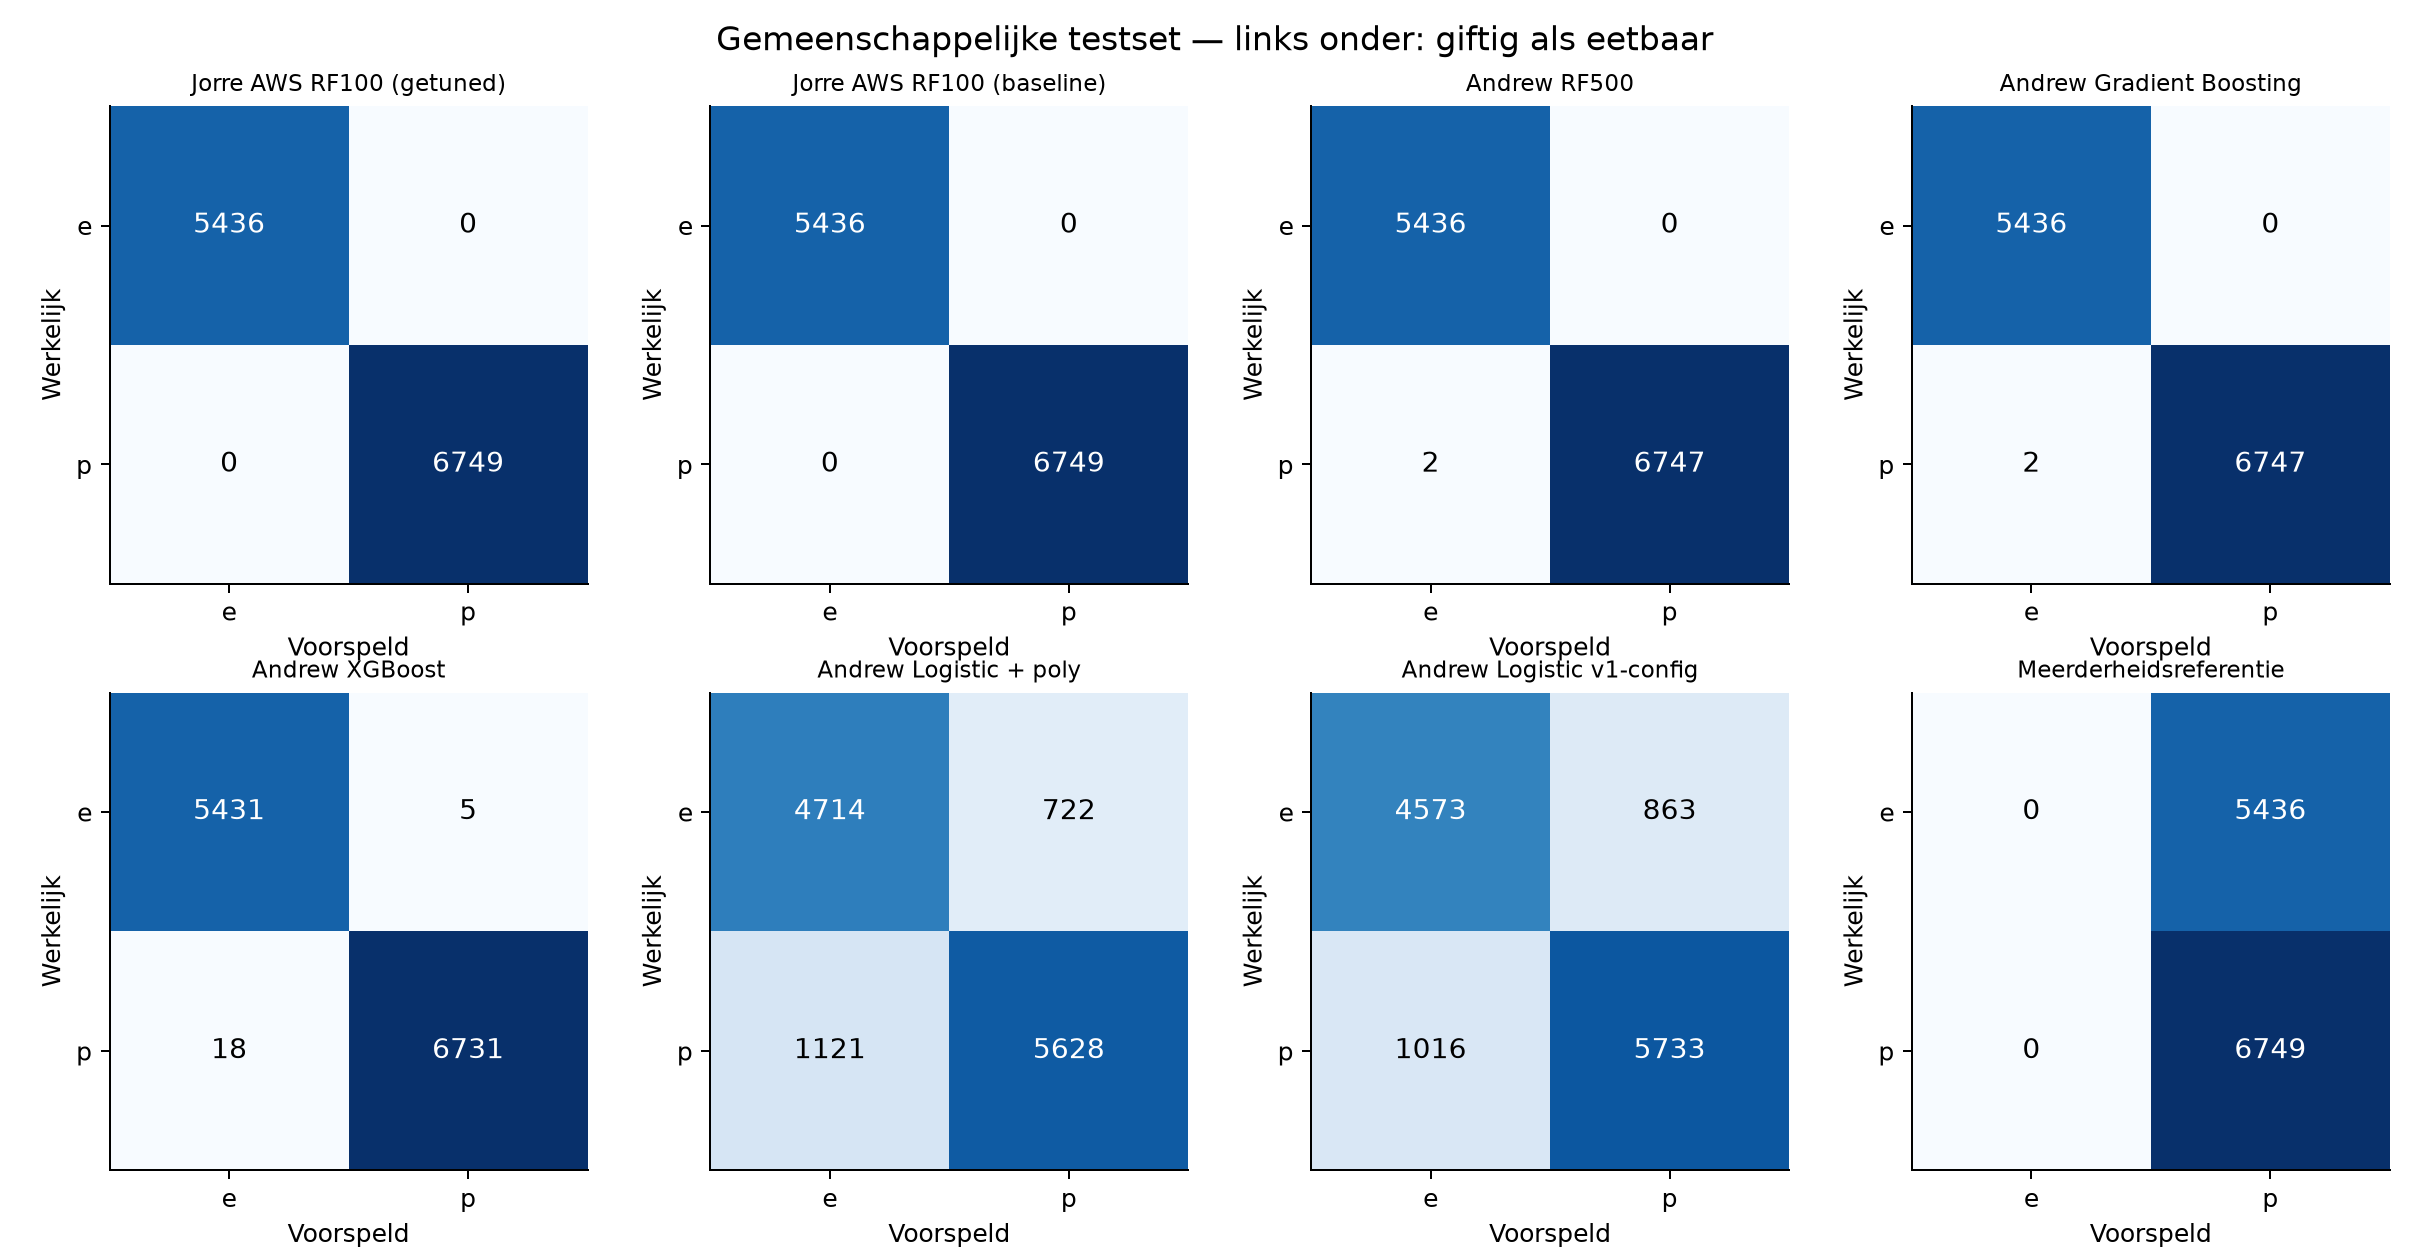

,tn,fp,fn,tp
model,,,,
aws_tuned,5436,0,0,6749
aws_baseline,5436,0,0,6749
random_forest_500,5436,0,2,6747
gradient_boosting,5436,0,2,6747
xgboost,5431,5,18,6731
logistic_polynomial,4714,722,1121,5628
logistic_artifact_config,4573,863,1016,5733
majority,0,5436,0,6749


,model,unique_row,source_row,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,...,veil-color,has-ring,ring-type,spore-print-color,habitat,season,true_class,predicted_class,probability_p,missing_features
2888,logistic_artifact_config,58573,58719,26.96,x,s,n,f,p,NaN,...,NaN,f,f,NaN,d,w,p,e,0.005188,6
3256,logistic_artifact_config,58756,58902,23.41,f,s,n,f,p,NaN,...,NaN,f,f,NaN,d,w,p,e,0.008153,6
3305,logistic_artifact_config,58488,58634,19.50,x,d,n,f,p,NaN,...,NaN,f,f,NaN,d,w,p,e,0.011454,6


aantal
model                    true_class predicted_class        
gradient_boosting        p          e                     2
logistic_artifact_config e          p                   863
                         p          e                  1016
logistic_polynomial      e          p                   722
                         p          e                  1121
random_forest_500        p          e                     2
xgboost                  e          p                     5
                         p          e                    18

Wilson 95% accuracy: [0.9996848380681895, 1.0]
Wilson 95% recall p: [0.9994311344573805, 0.9999999999999998]


In [6]:
display(Image(filename=str(OUT / 'shared_confusion_matrices.png')))
display(metrics[['tn', 'fp', 'fn', 'tp']].astype(int))
for key, row in metrics.iterrows():
    assert len(errors[errors.model == key]) == row.fn + row.fp
worst = metrics.drop(index='majority').sort_values('f1_poisonous').index[0]
display(errors[(errors.model == worst) & (errors.true_class == 'p')].sort_values('probability_p').head(3))
display(errors[errors.model != 'majority'].groupby(['model', 'true_class', 'predicted_class']).size().rename('aantal').to_frame())
chosen = next(row for row in summary['model_comparison'] if row['model'] == summary['selected_model'])
print('Wilson 95% accuracy:', chosen['accuracy_ci95'])
print('Wilson 95% recall p:', chosen['recall_ci95'])

De gepaarde accuracyvergelijking kijkt naar records waarop slechts één van de modellen
correct is. Bij AWS100 tegenover RF500/Gradient Boosting gaat het om twee zulke records
en p=0,5. De verschillen tussen de beste boommodellen zijn hier te klein voor een stellige
statistische conclusie. De overige toetsen zijn exploratief en niet gecorrigeerd voor
meerdere vergelijkingen; ze bepalen de modelkeuze niet.

In [7]:
display(pd.DataFrame(summary['pairwise_accuracy_audit']))

,selected,other,only_selected_correct,only_other_correct,mcnemar_exact_p
0,aws_tuned,aws_baseline,0,0,1.000000e+00
1,aws_tuned,random_forest_500,2,0,5.000000e-01
2,aws_tuned,gradient_boosting,2,0,5.000000e-01
3,aws_tuned,xgboost,23,0,2.384186e-07
4,aws_tuned,logistic_polynomial,1843,0,0.000000e+00
5,aws_tuned,logistic_artifact_config,1879,0,0.000000e+00


## 6a. Waarom 100%? Controle op volledig ongeziene soorten


100% is voor deze dataset niet op zichzelf bewijs van een programmeerfout. De auteurs
rapporteren voor Random Forest eveneens vijfvoudige CV accuracy en F2 van 1,0. Hun
gegevens zijn gesimuleerd met 353 voorbeelden per soort.
[Wagner et al., Scientific Reports](https://www.nature.com/articles/s41598-021-87602-3).

**Verificatie van de groepen.** Het originele archief bevat 173 primaire soorten en
61.069 secundaire records in 173 opeenvolgende blokken van 353. De audit controleert
de klassevolgorde en alle 2.941 combinaties van soort en categorisch kenmerk tegen
de primaire data, zonder afwijkingen. Pas daarna wordt `source_row // 353` als
groepsnummer gebruikt; de oorspronkelijke bronrij blijft na deduplicatie behouden.
De groeps-ID, soortnaam, rij-index en doelkolom worden nooit aan het model gevoerd.
Deze reconstructie is specifiek voor de gecontroleerde UCI-bestandsversie.

**Protocol.** Twee vaste volledige pipelineconfiguraties worden lokaal opnieuw gefit
met vijfvoudige `StratifiedGroupKFold`, shuffle en seed 42. Alle records van één soort
zitten in dezelfde validatiefold; elke fold heeft nul soortoverlap met training.
Imputatie en encoding worden binnen elke trainingsfold gefit. De opgeslagen AWS-pipeline
zelf is hiervoor niet gebruikt: die heeft al voorbeelden van alle soorten gezien.
De metrics hieronder worden gepoold over 60.923 voorspellingen buiten de training.
[scikit-learn: grouped cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data).

| Configuratie | Random test accuracy | Soorten apart: accuracy | Recall p | F1 p | FN |
| --- | --- | --- | --- | --- | --- |
| Jorre AWS RF100 (getuned) | 100.0000% | 62.84% | 66.95% | 0.666175 | 11153 |
| Andrew RF500 | 99.9836% | 65.93% | 68.37% | 0.689709 | 10674 |

![Random split tegenover ongeziene soorten](comparison_team/generalization_comparison.png)

De oorspronkelijke random test gebruikt 12.185 records; deze diagnostische groeps-CV
gebruikt 60.923 records met per fold opnieuw gefitte modellen. Het zijn verschillende
generalisatievragen en geen gepaarde vergelijking op één testset. Andrew RF500 scoort
in deze controle hoger dan AWS100, maar de overige kandidaten zijn niet met dit
groepsprotocol geëvalueerd. Hiermee is geen definitieve teamrangschikking vastgesteld.

**Negatieve controle.** Bij willekeurig geschudde labels haalt dezelfde AWS-configuratie
49.82% balanced accuracy en ROC-AUC 0.4964 op de oorspronkelijke random test.
Dat gedrag past bij toeval. Samen met het gecontroleerde featureschema levert dit
geen aanwijzing voor een rechtstreeks meegevoerde doelkolom; het sluit niet ieder
mogelijk datalek uit. De duidelijke terugval bij ongeziene soorten laat vooral zien
dat de random split de prestaties voor nieuwe soorten sterk overschat.

**Conclusie voor modelkeuze.** Voor interpolatie binnen deze 173 gesimuleerde soorten
blijft de random vergelijking bruikbaar. Voor ongeziene soorten moet het team alle
kandidaten en tuning met gescheiden soortgroepen vergelijken, en een ongebruikte
eindtest vastleggen. Deze audit is achteraf toegevoegd nadat de random scores bekend
waren en vormt geen nieuwe onaangeraakte eindtest. Ook soorten-CV test geen echte
veldmetingen. De eerdere brede conclusie dat AWS het beste model is, wordt ingetrokken.



In [8]:
generalization = json.loads((OUT / 'generalization_audit.json').read_text(encoding='utf-8'))
oof = pd.read_csv(OUT / 'species_oof_predictions.csv', float_precision='round_trip')
species_metrics = pd.read_csv(OUT / 'species_model_comparison.csv').set_index('model')
assert len(oof) == 60923 and oof.unique_row.is_unique
assert oof.groupby('species_group').validation_fold.nunique().eq(1).all()
assert oof.species_group.nunique() == 173
assert set(oof.validation_fold) == {1, 2, 3, 4, 5}
assert (oof.species_group == oof.source_row // 353).all()
assert oof[['unique_row', 'source_row']].equals(split[['unique_row', 'source_row']])
assert generalization['dataset']['sha256_lf'] == summary['dataset']['sha256_lf']
train_groups = set(oof.loc[split.split == 'train', 'species_group'])
test_groups = set(oof.loc[split.split == 'test', 'species_group'])
assert len(train_groups & test_groups) == 173
for fold in range(1, 6):
    assert not set(oof.loc[oof.validation_fold == fold, 'species_group']) & set(oof.loc[oof.validation_fold != fold, 'species_group'])
y_group = (oof.true_class == 'p').astype(int)
for key, row in species_metrics.iterrows():
    labels = (oof[key + '_prediction'] == 'p').astype(int)
    proba = oof[key + '_probability_p']
    for name, function in functions.items():
        actual = function(y_group, labels) if name in ['accuracy', 'balanced_accuracy'] else function(y_group, labels, zero_division=0)
        assert abs(actual - row[name]) < 1e-12
    assert abs(roc_auc_score(y_group, proba) - row.roc_auc) < 1e-12
    assert abs(average_precision_score(y_group, proba) - row.average_precision) < 1e-12
    assert confusion_matrix(y_group, labels, labels=[0, 1]).ravel().tolist() == [int(row[c]) for c in ['tn', 'fp', 'fn', 'tp']]
control = pd.read_csv(OUT / 'shuffled_label_predictions.csv', float_precision='round_trip')
import numpy as np
shuffled_targets = np.random.default_rng(42).permutation(y_group.to_numpy())
assert set(control.unique_row) == set(split.loc[split.split == 'test', 'unique_row'])
assert np.array_equal(control.shuffled_target, shuffled_targets[control.unique_row])
control_metrics = generalization['shuffled_label_negative_control']['metrics']
for name, function in functions.items():
    actual = function(control.shuffled_target, control.prediction) if name in ['accuracy', 'balanced_accuracy'] else function(control.shuffled_target, control.prediction, zero_division=0)
    assert abs(actual - control_metrics[name]) < 1e-12
assert abs(roc_auc_score(control.shuffled_target, control.probability_p) - control_metrics['roc_auc']) < 1e-12
display(species_metrics[['accuracy', 'recall_poisonous', 'f1_poisonous', 'fn', 'fp']].round(6))
display(pd.DataFrame(generalization['fold_membership']))
display(pd.Series(control_metrics, name='geschudde labels'))
print('Alle 173 soorten zaten in zowel random train als test; groeps-CV houdt soorten gescheiden.')
print('Twee vaste configuraties gecontroleerd; geen algemene winnaar geselecteerd.')

,accuracy,recall_poisonous,f1_poisonous,fn,fp
model,,,,,
aws_tuned,0.628400,0.669462,0.666175,11153,11486
random_forest_500,0.659308,0.683658,0.689709,10674,10082


,fold,train_rows,validation_rows,train_species,validation_species,overlapping_species
0,1,48580,12343,138,35,0
1,2,48921,12002,139,34,0
2,3,48347,12576,137,36,0
3,4,48922,12001,139,34,0
4,5,48922,12001,139,34,0


accuracy                  0.524826
balanced_accuracy         0.498228
precision_poisonous       0.552542
recall_poisonous          0.745813
f1_poisonous              0.634792
roc_auc                   0.496381
average_precision         0.546885
tn                     1363.000000
fp                     4075.000000
fn                     1715.000000
tp                     5032.000000
Name: geschudde labels, dtype: float64

Alle 173 soorten zaten in zowel random train als test; groeps-CV houdt soorten gescheiden.
Twee vaste configuraties gecontroleerd; geen algemene winnaar geselecteerd.


## 7. Trainingsgedrag, kosten en keuze


| Configuratie | Train F1 p | Test F1 p | Fit (s) | Proba 12.185 records (ms) | Pipeline (MiB) |
| --- | --- | --- | --- | --- | --- |
| Jorre AWS RF100 (getuned) | 1.000000 | 1.000000 | 7.11 | 163.20 | 1.765 |
| Jorre AWS RF100 (baseline) | 1.000000 | 1.000000 | 7.55 | 136.15 | 1.971 |
| Andrew RF500 | 0.999907 | 0.999852 | 10.13 | 289.26 | 8.820 |
| Andrew Gradient Boosting | 1.000000 | 0.999852 | 121.94 | 616.25 | 3.296 |
| Andrew XGBoost | 0.998573 | 0.998294 | 2.62 | 123.33 | 0.242 |
| Andrew Logistic + poly | 0.858052 | 0.859302 | 1.07 | 63.83 | 0.004 |
| Andrew Logistic v1-config | 0.855929 | 0.859198 | 0.75 | 58.52 | 0.004 |

Train-testverschillen kunnen op overfitting wijzen, maar zijn geen bewijs van één oorzaak.
Een zwakkere LR-score op train én test wijst op beperkingen van deze representatie of
instellingen; het bewijst niet dat alle lineaire modellen slecht zijn.

Tijden zijn lokale metingen op Windows 11 met twintig logische CPU's. Fit is één training
op 48.738 records; proba-tijd is de mediaan van vijf batches van 12.185 records; pipelinegrootte
is joblib-compressie 3 inclusief preprocessing. AWS-configuraties gebruiken twee threads,
Andrew RF/XGBoost `n_jobs=-1`. Dit is geen gecontroleerde vergelijking van algoritmische
rekenefficiëntie en geen Render-latencybenchmark. Modelgrootte en beschikbaarheid zijn wel
praktische afwegingen wanneer validatiescores gelijk zijn.

Er zijn exact gelijke beste CV F1- en recall-scores voor: **Jorre AWS RF100 (getuned), Jorre AWS RF100 (baseline)**. De vooraf vastgelegde voorkeur kiest bij zulke gelijke scores het reeds beschikbare, geregulariseerde AWS RF100 als die configuratie ertussen staat. Dit geldt uitsluitend binnen de oorspronkelijke random split.
De aanvullende soortcontrole ondersteunt geen algemene voorkeur voor AWS.
De keuze binnen de random split wordt niet voorgesteld als
een statistisch bewezen uniek beste model. Het AWS-notebookmodel is beschikbaar als complete
pipeline; een gedeelde prestatie zou op zichzelf geen reden zijn om een veel groter model
naar de backend te verhuizen.



In [9]:
practical = metrics.drop(index='majority')[['train_accuracy', 'accuracy', 'train_f1_poisonous', 'f1_poisonous', 'fit_seconds', 'predict_12185_ms']].copy()
practical['pipeline MiB (compressie 3)'] = metrics.serialized_bytes_compress3 / 2**20
display(practical.round(6))
display(pd.Series({key: sum(counts.values()) for key, counts in summary['warnings'].items()}, name='waarschuwingen per run'))

,train_accuracy,accuracy,train_f1_poisonous,f1_poisonous,fit_seconds,predict_12185_ms,pipeline MiB (compressie 3)
model,,,,,,,
aws_tuned,1.000000,1.000000,1.000000,1.000000,7.105864,163.2020,1.765139
aws_baseline,1.000000,1.000000,1.000000,1.000000,7.546203,136.1466,1.970715
random_forest_500,0.999897,0.999836,0.999907,0.999852,10.126356,289.2650,8.819592
gradient_boosting,1.000000,0.999836,1.000000,0.999852,121.942573,616.2536,3.295702
xgboost,0.998420,0.998112,0.998573,0.998294,2.624066,123.3324,0.242268
logistic_polynomial,0.848127,0.848748,0.858052,0.859302,1.068006,63.8301,0.003695
logistic_artifact_config,0.842710,0.845794,0.855929,0.859198,0.749411,58.5190,0.003502


aws_tuned_cv                         0
aws_baseline_cv                      0
random_forest_500_cv                 0
gradient_boosting_cv                 0
xgboost_cv                           0
logistic_polynomial_cv               0
logistic_artifact_config_cv          0
majority_cv                          0
aws_tuned_full_fit                   0
aws_baseline_full_fit                0
random_forest_500_full_fit           0
gradient_boosting_full_fit           0
xgboost_full_fit                     0
logistic_polynomial_full_fit         0
logistic_artifact_config_full_fit    0
majority_full_fit                    0
Name: waarschuwingen per run, dtype: int64

## 8. Conclusie en resterend werk


**Geen algemeen beste model vastgesteld.** De eerdere voorkeur voor AWS geldt alleen
voor een willekeurige rij-split binnen dezelfde gesimuleerde soorten. In een aanvullende
controle met volledige soorten buiten de training haalt de AWS-configuratie **62.84%
accuracy**, tegenover **65.93%** voor Andrew RF500. De oorspronkelijke 100% bewijst dus
geen perfecte generalisatie. Zie sectie 6a voor het protocol en de bewaarde voorspellingen.

**Voorlopige voorkeur binnen de oorspronkelijke random split: Jorre AWS RF100 (getuned).**
De gemiddelde CV F1 p is **1.000000**. Op dezelfde 12.185 testrecords
haalt de nieuwe lokale fit **100.0000% accuracy**, met **0
giftige records als eetbaar** en **0 eetbare records als giftig**.
Er zijn exact gelijke beste CV F1- en recall-scores voor: **Jorre AWS RF100 (getuned), Jorre AWS RF100 (baseline)**. De vooraf vastgelegde voorkeur kiest bij zulke gelijke scores het reeds beschikbare, geregulariseerde AWS RF100 als die configuratie ertussen staat.

Het **ongewijzigde opgeslagen AWS-model** is daarnaast apart gecontroleerd in scikit-learn
1.7.2: de oorspronkelijke 100%-scores en confusion matrix worden gereproduceerd, met
0 FN en 0 FP. De nieuwe gezamenlijke vergelijking bestaat uit **lokale hertrainingen van
modelconfiguraties**. Andrew's oorspronkelijke 5.000-rijenmodellen krijgen daarmee geen
nieuwe scores toegeschreven: hun input is voor dit experiment aangepast naar dezelfde
twintig oorspronkelijke UCI-features. De historisch gemelde 81% en AWS 100% worden dus
niet rechtstreeks als gelijke experimenten gerangschikt.

De gedeelde testset was eerder in het AWS-notebook bekeken. Deze conclusie is een
ontwikkelbesluit, geen bewijs van perfecte generalisatie naar nieuwe soorten of echte
paddenstoelen. De API wordt door dit rapport niet naar een ander model omgeschakeld.




De opdracht vraagt ook AutoML, systematische tuning, uitleg per model, EDA en een werkende
deploymentpipeline. De gezamenlijke vergelijking vult alleen het modelvergelijkingsdeel aan.
Voor de definitieve inlevering zijn onder meer nog nodig:

1. Leg het uiteindelijke probleem en generalisatiedoel vast. Een random split binnen
   gesimuleerde soorten is geen test op nieuwe soorten of echte paddenstoelen. Gebruik
   bij het doel 'nieuwe soorten' het gecontroleerde groepsprotocol voor alle kandidaten.
2. Voeg ontbrekende AutoML/team-experimenten toe aan hetzelfde datacontract en protocol.
   Behoud tuninglogs; rapporteer ook experimenten zonder verbetering.
3. Gebruik een eindtest die niet al voor ontwikkeling is bekeken, of motiveer een passend
   alternatief. Het huidige AWS-testresultaat is eerder bekend geweest.
4. Laat het team de preprocessing, metrickeuze, tie-breaker en concrete fouten reviewen
   en zelf kunnen uitleggen. Gebruik modelbestanden met de passende versies.
5. Als het team voor het AWS-model kiest: pas API en frontend bewust van Andrew's twaalf
   velden naar de twintig AWS-features aan, en valideer voorspellingen tegen het notebook.
   Het gepubliceerde model is op dit moment nog de oudere RF200.

Het laden van een scikit-learn-pipeline uit een andere versie is geen betrouwbare migratie;
zie [model persistence](https://scikit-learn.org/stable/model_persistence.html).
Deze uitbreiding heeft de originele bronnotebooks en modelbestanden niet aangepast.



## 9. Reproduceren en bewijsbestanden


Voer vanuit de repositoryroot twee afzonderlijke omgevingen uit:

```powershell
py -3.13 -m venv .venv-aws-audit
.\.venv-aws-audit\Scripts\python.exe -m pip install -r secondary_mushroom/requirements-aws-audit.txt
.\.venv-aws-audit\Scripts\python.exe secondary_mushroom/audit_aws_model.py

py -3.13 -m venv .venv-analysis
.\.venv-analysis\Scripts\python.exe -m pip install -r secondary_mushroom/comparison-requirements.txt
.\.venv-analysis\Scripts\python.exe secondary_mushroom/compare_team_models.py
.\.venv-analysis\Scripts\python.exe secondary_mushroom/audit_species_generalization.py
.\.venv-analysis\Scripts\python.exe secondary_mushroom/build_team_comparison_report.py --execute
```

De twee omgevingen scheiden het laden van het originele artifact (1.7.2) van nieuwe fits
(1.9.1). De notebooks laden standaard de bewaarde resultaten; een volledige hertraining
gebeurt met het script of `RUN_TRAINING=True`. Op andere hardware kunnen timing en sommige
numerieke uitkomsten veranderen. Bewaar bij nieuwe runs de hashes, parameters en versies.

| Bestand | Inhoud |
| --- | --- |
| [09_compare_models.ipynb](09_compare_models.ipynb) | Uitgevoerd hoofdnotebook: Andrew + Jorre/AWS |
| [09_compare_andrew_models.ipynb](09_compare_andrew_models.ipynb) | Historische reproductie van Andrew's eigen 5.000-rijenexperiment |
| [audit_aws_model.py](audit_aws_model.py) | Controle van het ongewijzigde opgeslagen AWS-model |
| [compare_team_models.py](compare_team_models.py) | Gezamenlijke lokale training en CV-selectie |
| [audit_species_generalization.py](audit_species_generalization.py) | Groepsverificatie, vijfvoudige soorten-CV en geschudde-labelcontrole |
| [generalization_audit.json](comparison_team/generalization_audit.json) | Soortoverlap, groepsprotocol en diagnostische resultaten |
| [species_lookup.csv](comparison_team/species_lookup.csv) | Gecontroleerde koppeling van groeps-ID naar primaire soort |
| [species_cv_folds.csv](comparison_team/species_cv_folds.csv) | Alle tien model/fold-evaluaties |
| [species_model_comparison.csv](comparison_team/species_model_comparison.csv) | Gepoolde metrics bij ongeziene soorten |
| [species_oof_predictions.csv](comparison_team/species_oof_predictions.csv) | Voorspelling, bronrij, soortgroep en validatiefold van alle unieke records |
| [shuffled_label_predictions.csv](comparison_team/shuffled_label_predictions.csv) | Individuele voorspellingen van de negatieve controle |
| [comparison_data.py](comparison_data.py) | Gecodeerde UCI-download, deduplicatie en gedeelde split |
| [build_team_comparison_report.py](build_team_comparison_report.py) | Rapport en uitgevoerd notebook opbouwen |
| [aws_artifact_audit.json](comparison_team/aws_artifact_audit.json) | Modelhash, schema, omgeving en opnieuw berekende AWS-scores |
| [aws_artifact_predictions.csv](comparison_team/aws_artifact_predictions.csv) | Alle voorspellingen van het oorspronkelijke AWS-artifact |
| [shared_comparison_summary.json](comparison_team/shared_comparison_summary.json) | Gedeelde parameters, versies, scores en keuze |
| [shared_cv_folds.csv](comparison_team/shared_cv_folds.csv) | Alle 24 model/fold-evaluaties |
| [shared_split_manifest.csv](comparison_team/shared_split_manifest.csv) | Unieke rij-index, originele bronrij, train/test en fold |
| [shared_model_comparison.csv](comparison_team/shared_model_comparison.csv) | Exacte vergelijkingstabel |
| [shared_test_predictions.csv](comparison_team/shared_test_predictions.csv) | Labels en p-scores per model op dezelfde testrecords |
| [shared_error_records.csv](comparison_team/shared_error_records.csv) | Concrete foutrecords per model |
